# Lab 5: Phân loại Văn bản với Mạng Nơ-ron Hồi quy (RNN/LSTM)

## Bước 0: Thiết lập Môi trường và Import Libraries

In [29]:
!pip install gensim
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, f1_score, accuracy_score

# Gensim for Word2Vec
from gensim.models import Word2Vec

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: []


## Bước 1: Tải và Khám phá Dữ liệu

In [30]:
# Tải dữ liệu
df_train = pd.read_csv('/content/data/hwu/test.csv')
df_val = pd.read_csv('/content/data/hwu/val.csv')
df_test = pd.read_csv('/content/data/hwu/test.csv')

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)
print("\nFirst 5 samples:")
df_train.head()

Train shape: (1076, 2)
Validation shape: (1076, 2)
Test shape: (1076, 2)

First 5 samples:


,text,category
0,tell me time of alarm you set,alarm_query
1,list all of my alarms,alarm_query
2,alarm settings,alarm_query
3,what alarms are set for today,alarm_query
4,please see see for me the alarms that you have...,alarm_query


In [31]:
# Kiểm tra tên cột
print("Columns:", df_train.columns.tolist())
print("\nSample data:")
print(df_train.head())

# Thống kê về các intent (category)
print("\nNumber of unique categories:", df_train['category'].nunique())
print("\nCategory distribution:")
print(df_train['category'].value_counts().head(10))

Columns: ['text', 'category']

Sample data:
                                                text     category
0                      tell me time of alarm you set  alarm_query
1                              list all of my alarms  alarm_query
2                                     alarm settings  alarm_query
3                      what alarms are set for today  alarm_query
4  please see see for me the alarms that you have...  alarm_query

Number of unique categories: 64

Category distribution:
category
alarm_query           19
alarm_set             19
calendar_query        19
calendar_remove       19
email_query           19
datetime_query        19
cooking_recipe        19
calendar_set          19
email_sendemail       19
email_querycontact    19
Name: count, dtype: int64


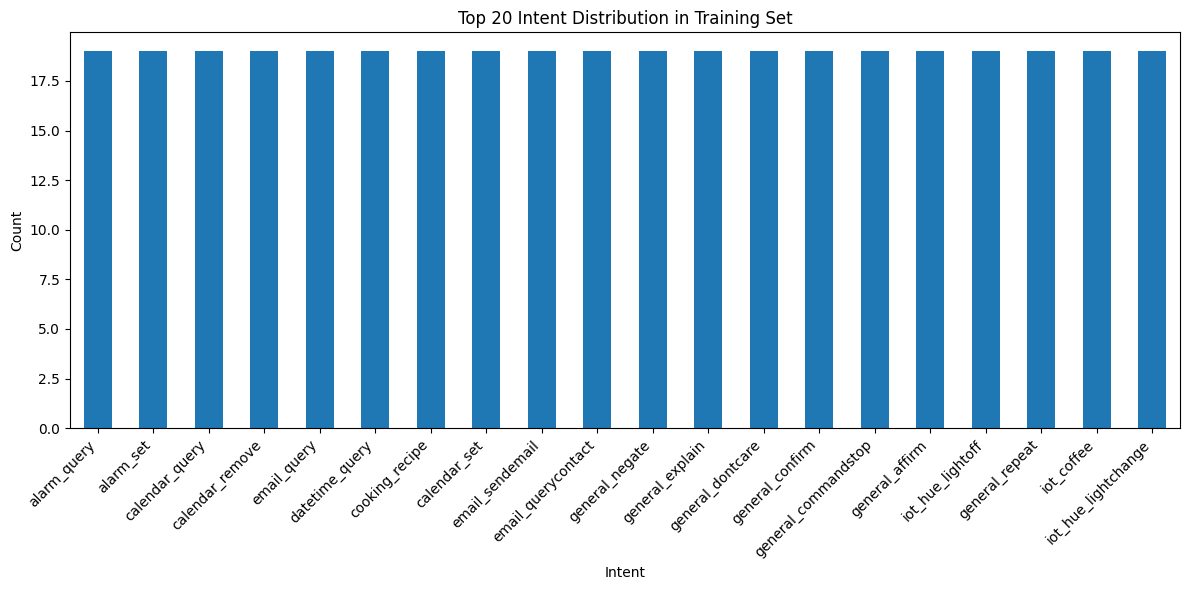


Text length statistics:
count    1076.000000
mean        6.690520
std         3.025157
min         1.000000
25%         5.000000
50%         6.000000
75%         8.000000
max        21.000000
Name: text_length, dtype: float64


In [32]:
# Visualize phân phối intent
plt.figure(figsize=(12, 6))
df_train['category'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Intent Distribution in Training Set')
plt.xlabel('Intent')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Thống kê độ dài câu
df_train['text_length'] = df_train['text'].apply(lambda x: len(x.split()))
print("\nText length statistics:")
print(df_train['text_length'].describe())

## Bước 2: Tiền xử lý Dữ liệu

In [33]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(pd.concat([df_train['category'], df_val['category'], df_test['category']]))

y_train = label_encoder.transform(df_train['category'])
y_val = label_encoder.transform(df_val['category'])
y_test = label_encoder.transform(df_test['category'])

num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_[:10]}...")  # Show first 10

Number of classes: 64
Classes: ['alarm_query' 'alarm_remove' 'alarm_set' 'audio_volume_down'
 'audio_volume_mute' 'audio_volume_up' 'calendar_query' 'calendar_remove'
 'calendar_set' 'cooking_recipe']...


In [34]:
# Prepare text data
X_train_text = df_train['text'].values
X_val_text = df_val['text'].values
X_test_text = df_test['text'].values

print(f"Train samples: {len(X_train_text)}")
print(f"Validation samples: {len(X_val_text)}")
print(f"Test samples: {len(X_test_text)}")

Train samples: 1076
Validation samples: 1076
Test samples: 1076


## Nhiệm vụ 1: Pipeline TF-IDF + Logistic Regression (Baseline 1)

In [35]:
# Tạo pipeline
tfidf_lr_pipeline = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
)

# Huấn luyện
print("\nTraining TF-IDF + Logistic Regression...")
tfidf_lr_pipeline.fit(X_train_text, y_train)

# Dự đoán
y_pred_tfidf_lr = tfidf_lr_pipeline.predict(X_test_text)

# Đánh giá
accuracy_tfidf_lr = accuracy_score(y_test, y_pred_tfidf_lr)
f1_macro_tfidf_lr = f1_score(y_test, y_pred_tfidf_lr, average='macro')

print(f"\nAccuracy: {accuracy_tfidf_lr:.4f}")
print(f"F1-score (Macro): {f1_macro_tfidf_lr:.4f}")
print("\nClassification Report (first 10 classes):")
print(classification_report(y_test, y_pred_tfidf_lr,
                          target_names=label_encoder.classes_,
                          digits=4))


Training TF-IDF + Logistic Regression...

Accuracy: 0.9647
F1-score (Macro): 0.9363

Classification Report (first 10 classes):
                          precision    recall  f1-score   support

             alarm_query     0.8571    0.9474    0.9000        19
            alarm_remove     1.0000    0.6364    0.7778        11
               alarm_set     0.9474    0.9474    0.9474        19
       audio_volume_down     1.0000    1.0000    1.0000         8
       audio_volume_mute     1.0000    0.8667    0.9286        15
         audio_volume_up     1.0000    1.0000    1.0000        13
          calendar_query     1.0000    1.0000    1.0000        19
         calendar_remove     0.9500    1.0000    0.9744        19
            calendar_set     1.0000    0.9474    0.9730        19
          cooking_recipe     1.0000    1.0000    1.0000        19
        datetime_convert     1.0000    0.6250    0.7692         8
          datetime_query     0.8636    1.0000    0.9268        19
        email

## Nhiệm vụ 2: Pipeline Word2Vec (Trung bình) + Dense Layer (Baseline 2)

In [36]:
# Chuẩn bị dữ liệu cho Word2Vec
sentences_train = [text.lower().split() for text in X_train_text]
sentences_val = [text.lower().split() for text in X_val_text]
sentences_test = [text.lower().split() for text in X_test_text]

# Huấn luyện Word2Vec
print("\nTraining Word2Vec model...")
w2v_model = Word2Vec(
    sentences=sentences_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=10,
    seed=42
)

print(f"Vocabulary size: {len(w2v_model.wv)}")
print(f"Vector size: {w2v_model.vector_size}")


Training Word2Vec model...
Vocabulary size: 1454
Vector size: 100


In [37]:
# Hàm chuyển câu thành vector trung bình
def sentence_to_avg_vector(sentence, model):
    """
    Chuyển một câu thành vector trung bình của các từ trong câu.
    """
    words = sentence.lower().split()
    word_vectors = []

    for word in words:
        if word in model.wv:
            word_vectors.append(model.wv[word])

    if len(word_vectors) > 0:
        return np.mean(word_vectors, axis=0)
    else:
        # Trả về vector 0 nếu không có từ nào trong vocab
        return np.zeros(model.vector_size)

# Chuyển đổi dữ liệu
print("Converting sentences to average vectors...")
X_train_w2v = np.array([sentence_to_avg_vector(text, w2v_model) for text in X_train_text])
X_val_w2v = np.array([sentence_to_avg_vector(text, w2v_model) for text in X_val_text])
X_test_w2v = np.array([sentence_to_avg_vector(text, w2v_model) for text in X_test_text])

print(f"X_train_w2v shape: {X_train_w2v.shape}")
print(f"X_val_w2v shape: {X_val_w2v.shape}")
print(f"X_test_w2v shape: {X_test_w2v.shape}")

Converting sentences to average vectors...
X_train_w2v shape: (1076, 100)
X_val_w2v shape: (1076, 100)
X_test_w2v shape: (1076, 100)


In [38]:
# Chuyển labels sang one-hot encoding
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# Xây dựng mô hình Dense với 3 hidden layers
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

print("\nBuilding Word2Vec + Dense model (3 hidden layers)...")
w2v_dense_model = Sequential([
    # Layer 1: Input layer
    Dense(256, activation='relu', input_shape=(w2v_model.vector_size,)),
    BatchNormalization(),
    Dropout(0.4),

    # Layer 2: Hidden layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Layer 3: Hidden layer
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),

    # Output layer
    Dense(num_classes, activation='softmax')
])

w2v_dense_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

w2v_dense_model.summary()


Building Word2Vec + Dense model (3 hidden layers)...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,960 (285.00 KB)

 Trainable params: 72,064 (281.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [39]:
# Huấn luyện mô hình
print("\nTraining Word2Vec + Dense model...")
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

history_w2v = w2v_dense_model.fit(
    X_train_w2v, y_train_cat,
    validation_data=(X_val_w2v, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Training Word2Vec + Dense model...
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.0108 - loss: 4.7796 - val_accuracy: 0.0084 - val_loss: 4.1590
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0218 - loss: 4.6361 - val_accuracy: 0.0177 - val_loss: 4.1620
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0103 - loss: 4.5529 - val_accuracy: 0.0204 - val_loss: 4.1633
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0182 - loss: 4.5309 - val_accuracy: 0.0260 - val_loss: 4.1573
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0283 - loss: 4.4673 - val_accuracy: 0.0177 - val_loss: 4.1543
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0220 - loss: 4.3988 - val_accuracy: 0.0232 - val_loss: 4.1559
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0226 - loss: 4.3778 - val_accuracy: 0.0214 - val_loss: 4.1518
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0385 - loss: 4.

In [40]:
# Đánh giá mô hình
print("\nEvaluating Word2Vec + Dense model...")
test_loss_w2v, test_acc_w2v = w2v_dense_model.evaluate(X_test_w2v, y_test_cat, verbose=0)

y_pred_w2v_proba = w2v_dense_model.predict(X_test_w2v, verbose=0)
y_pred_w2v = np.argmax(y_pred_w2v_proba, axis=1)

f1_macro_w2v = f1_score(y_test, y_pred_w2v, average='macro')

print(f"\nTest Loss: {test_loss_w2v:.4f}")
print(f"Test Accuracy: {test_acc_w2v:.4f}")
print(f"F1-score (Macro): {f1_macro_w2v:.4f}")


Evaluating Word2Vec + Dense model...

Test Loss: 4.0686
Test Accuracy: 0.0418
F1-score (Macro): 0.0102


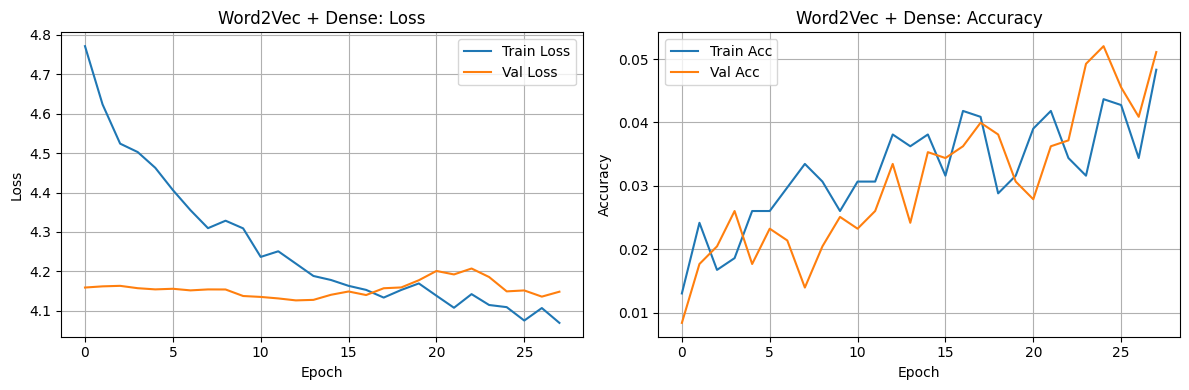

In [41]:
# Vẽ biểu đồ training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_w2v.history['loss'], label='Train Loss')
plt.plot(history_w2v.history['val_loss'], label='Val Loss')
plt.title('Word2Vec + Dense: Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_w2v.history['accuracy'], label='Train Acc')
plt.plot(history_w2v.history['val_accuracy'], label='Val Acc')
plt.title('Word2Vec + Dense: Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Chuẩn bị dữ liệu cho mô hình LSTM

In [42]:
# Tokenizer
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train_text)

# Chuyển text thành sequences
train_sequences = tokenizer.texts_to_sequences(X_train_text)
val_sequences = tokenizer.texts_to_sequences(X_val_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text)

# Padding
max_len = 50
X_train_pad = pad_sequences(train_sequences, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(val_sequences, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(test_sequences, maxlen=max_len, padding='post')

print(f"\nVocabulary size: {len(tokenizer.word_index) + 1}")
print(f"Max sequence length: {max_len}")
print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_val_pad shape: {X_val_pad.shape}")
print(f"X_test_pad shape: {X_test_pad.shape}")


Vocabulary size: 1402
Max sequence length: 50
X_train_pad shape: (1076, 50)
X_val_pad shape: (1076, 50)
X_test_pad shape: (1076, 50)


## Nhiệm vụ 3: Mô hình Embedding (Pre-trained) + LSTM

In [43]:
# Tạo ma trận embedding từ Word2Vec
word_index = tokenizer.word_index
vocab_size_actual = min(len(word_index) + 1, vocab_size)
embedding_dim = w2v_model.vector_size

print(f"\nCreating embedding matrix...")
embedding_matrix = np.zeros((vocab_size_actual, embedding_dim))

found_words = 0
for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
        found_words += 1

print(f"Found {found_words}/{vocab_size_actual} words in Word2Vec model")
print(f"Coverage: {found_words/vocab_size_actual*100:.2f}%")


Creating embedding matrix...
Found 1366/1402 words in Word2Vec model
Coverage: 97.43%


In [44]:
# Xây dựng mô hình LSTM với pre-trained embeddings
print("\nBuilding LSTM model with pre-trained embeddings...")
lstm_pretrained_model = Sequential([
    Embedding(
        input_dim=vocab_size_actual,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False  # Đóng băng embedding layer
    ),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(num_classes, activation='softmax')
])

lstm_pretrained_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_pretrained_model.build(input_shape=(None, max_len))

lstm_pretrained_model.summary()


Building LSTM model with pre-trained embeddings...


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 100)        │       140,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,704 (1.01 MB)

 Trainable params: 125,504 (490.25 KB)

 Non-trainable params: 140,200 (547.66 KB)

In [45]:
# Huấn luyện mô hình
print("\nTraining LSTM model with pre-trained embeddings...")
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_lstm_pretrained = lstm_pretrained_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop]
)


Training LSTM model with pre-trained embeddings...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 614ms/step - accuracy: 0.0150 - loss: 4.1589 - val_accuracy: 0.0195 - val_loss: 4.1573
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - accuracy: 0.0182 - loss: 4.1571 - val_accuracy: 0.0251 - val_loss: 4.1553
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 432ms/step - accuracy: 0.0155 - loss: 4.1545 - val_accuracy: 0.0177 - val_loss: 4.1507
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 421ms/step - accuracy: 0.0135 - loss: 4.1488 - val_accuracy: 0.0177 - val_loss: 4.1354
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 721ms/step - accuracy: 0.0165 - loss: 4.1427 - val_accuracy: 0.0177 - val_loss: 4.1315
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 419ms/step - accuracy: 0.0192 - loss: 4.1334 - val_accuracy: 0.0177 - val_loss: 4.1354
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step - accuracy: 0.0209 - loss: 4.1366 - val_accuracy: 0.0177 - val_loss: 4.1320
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 416ms/step - accuracy: 0.01

In [46]:
# Đánh giá mô hình
print("\nEvaluating LSTM model with pre-trained embeddings...")
test_loss_lstm_pre, test_acc_lstm_pre = lstm_pretrained_model.evaluate(X_test_pad, y_test_cat, verbose=0)

y_pred_lstm_pre_proba = lstm_pretrained_model.predict(X_test_pad)
y_pred_lstm_pre = np.argmax(y_pred_lstm_pre_proba, axis=1)

f1_macro_lstm_pre = f1_score(y_test, y_pred_lstm_pre, average='macro')

print(f"\nTest Loss: {test_loss_lstm_pre:.4f}")
print(f"Test Accuracy: {test_acc_lstm_pre:.4f}")
print(f"F1-score (Macro): {f1_macro_lstm_pre:.4f}")


Evaluating LSTM model with pre-trained embeddings...
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step

Test Loss: 3.9959
Test Accuracy: 0.0474
F1-score (Macro): 0.0104


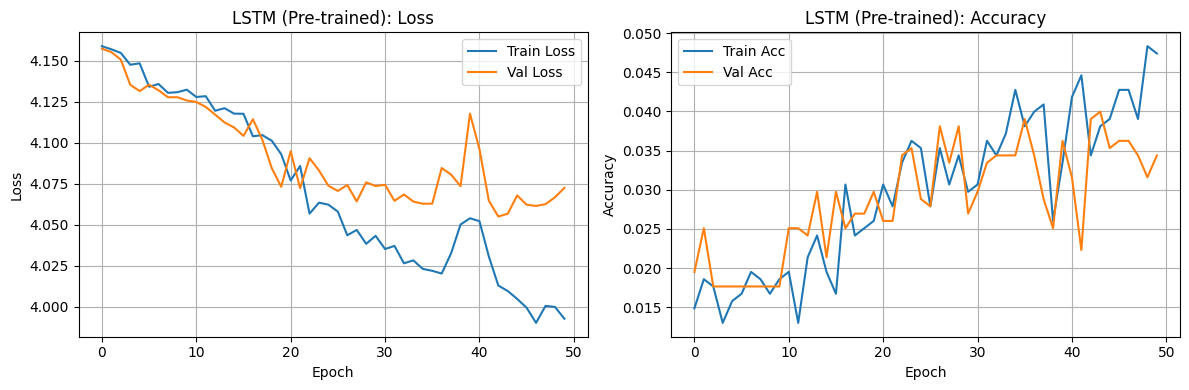

In [47]:
# Vẽ biểu đồ training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_lstm_pretrained.history['loss'], label='Train Loss')
plt.plot(history_lstm_pretrained.history['val_loss'], label='Val Loss')
plt.title('LSTM (Pre-trained): Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_lstm_pretrained.history['accuracy'], label='Train Acc')
plt.plot(history_lstm_pretrained.history['val_accuracy'], label='Val Acc')
plt.title('LSTM (Pre-trained): Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Nhiệm vụ 4: Mô hình Embedding (Học từ đầu) + LSTM

In [48]:
# Xây dựng mô hình LSTM với embedding học từ đầu
print("\nBuilding LSTM model with trainable embeddings from scratch...")

lstm_scratch_model = Sequential([
    # Embedding layer - học từ đầu, không có weights pre-trained
    Embedding(
        input_dim=vocab_size_actual,
        output_dim=100,  # Chiều embedding 100
        input_length=max_len
        # trainable=True (mặc định)
    ),

    # LSTM layer với dropout
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),

    # Output layer
    Dense(num_classes, activation='softmax')
])

# Compile model
lstm_scratch_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_scratch_model.build(input_shape=(None, max_len))

lstm_scratch_model.summary()



Building LSTM model with trainable embeddings from scratch...


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 100)        │       140,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,704 (1.01 MB)

 Trainable params: 265,704 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history_lstm_scratch = lstm_scratch_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=50,
    batch_size=256,
    callbacks=early_stop,
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 632ms/step - accuracy: 0.0234 - loss: 4.1588 - val_accuracy: 0.0177 - val_loss: 4.1523
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 890ms/step - accuracy: 0.0116 - loss: 4.1508 - val_accuracy: 0.0177 - val_loss: 4.1454
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 501ms/step - accuracy: 0.0228 - loss: 4.1445 - val_accuracy: 0.0177 - val_loss: 4.1392
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 471ms/step - accuracy: 0.0171 - loss: 4.1397 - val_accuracy: 0.0177 - val_loss: 4.1355
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 0.0136 - loss: 4.1395 - val_accuracy: 0.0177 - val_loss: 4.1329
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 488ms/step - accuracy: 0.0199 - loss: 4.1392 - val_accuracy: 0.0177 - val_loss: 4.1312
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 851ms/step - accuracy: 0.0236 - loss: 4.1293 - val_accuracy: 0.0177 - val_loss: 4.1301
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 507ms/step - accuracy: 0.0215 - loss: 4.1236 - val_accuracy: 0.0177 - val_loss:

In [50]:
# Đánh giá mô hình
print("\nEvaluating LSTM model with trainable embeddings...")
test_loss_lstm_scratch, test_acc_lstm_scratch = lstm_scratch_model.evaluate(X_test_pad, y_test_cat, verbose=0)

y_pred_lstm_scratch_proba = lstm_scratch_model.predict(X_test_pad)
y_pred_lstm_scratch = np.argmax(y_pred_lstm_scratch_proba, axis=1)

f1_macro_lstm_scratch = f1_score(y_test, y_pred_lstm_scratch, average='macro')

print(f"\nTest Loss: {test_loss_lstm_scratch:.4f}")
print(f"Test Accuracy: {test_acc_lstm_scratch:.4f}")
print(f"F1-score (Macro): {f1_macro_lstm_scratch:.4f}")


Evaluating LSTM model with trainable embeddings...
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step

Test Loss: 4.1244
Test Accuracy: 0.0177
F1-score (Macro): 0.0005


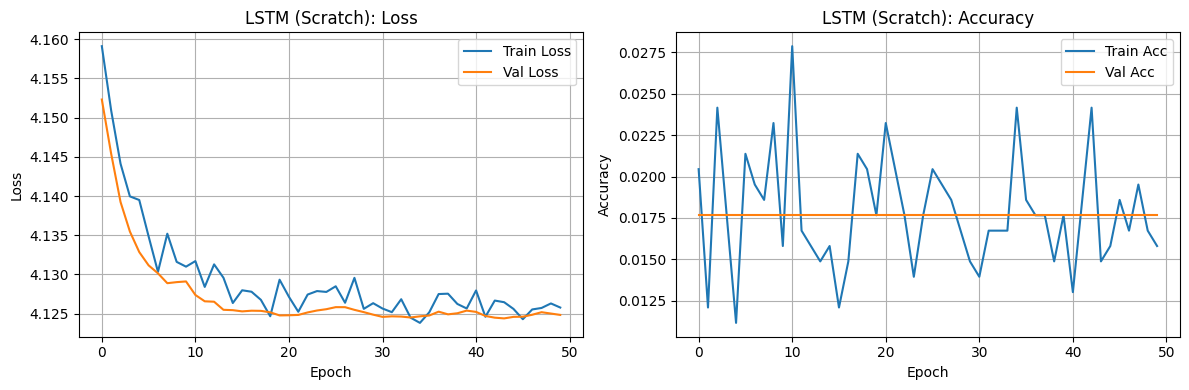

In [51]:
# Vẽ biểu đồ training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_lstm_scratch.history['loss'], label='Train Loss')
plt.plot(history_lstm_scratch.history['val_loss'], label='Val Loss')
plt.title('LSTM (Scratch): Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_lstm_scratch.history['accuracy'], label='Train Acc')
plt.plot(history_lstm_scratch.history['val_accuracy'], label='Val Acc')
plt.title('LSTM (Scratch): Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Nhiệm vụ 5: Đánh giá, So sánh và Phân tích

### 5.1. So sánh Định lượng

In [52]:
# Tạo bảng so sánh kết quả
results = pd.DataFrame({
    'Pipeline': [
        'TF-IDF + Logistic Regression',
        'Word2Vec (Avg) + Dense',
        'Embedding (Pre-trained) + LSTM',
        'Embedding (Scratch) + LSTM'
    ],
    'Accuracy': [
        accuracy_tfidf_lr,
        test_acc_w2v,
        test_acc_lstm_pre,
        test_acc_lstm_scratch
    ],
    'F1-score (Macro)': [
        f1_macro_tfidf_lr,
        f1_macro_w2v,
        f1_macro_lstm_pre,
        f1_macro_lstm_scratch
    ],
    'Test Loss': [
        'N/A',
        f"{test_loss_w2v:.4f}",
        f"{test_loss_lstm_pre:.4f}",
        f"{test_loss_lstm_scratch:.4f}"
    ]
})

print("="*80)
print("BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH")
print("="*80)
print(results.to_string(index=False))
print("="*80)

BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH
                      Pipeline  Accuracy  F1-score (Macro) Test Loss
  TF-IDF + Logistic Regression  0.964684          0.936326       N/A
        Word2Vec (Avg) + Dense  0.041822          0.010221    4.0686
Embedding (Pre-trained) + LSTM  0.047398          0.010429    3.9959
    Embedding (Scratch) + LSTM  0.017658          0.000542    4.1244


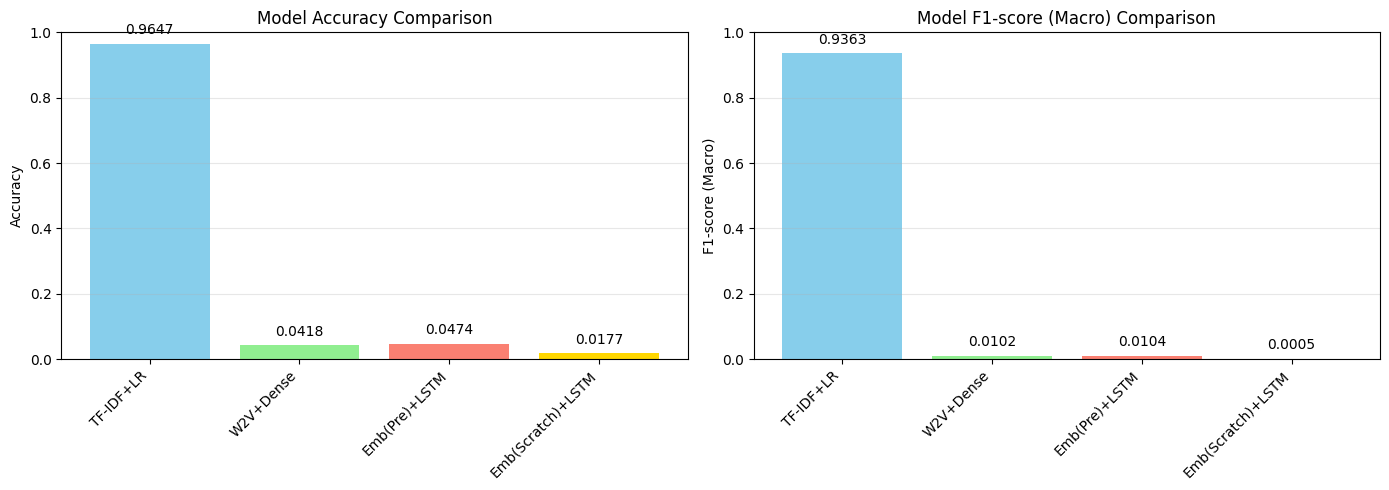

In [53]:
# Visualize so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].bar(range(len(results)), results['Accuracy'], color=['skyblue', 'lightgreen', 'salmon', 'gold'])
axes[0].set_xticks(range(len(results)))
axes[0].set_xticklabels(['TF-IDF+LR', 'W2V+Dense', 'Emb(Pre)+LSTM', 'Emb(Scratch)+LSTM'], rotation=45, ha='right')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(results['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')

# F1-score comparison
axes[1].bar(range(len(results)), results['F1-score (Macro)'], color=['skyblue', 'lightgreen', 'salmon', 'gold'])
axes[1].set_xticks(range(len(results)))
axes[1].set_xticklabels(['TF-IDF+LR', 'W2V+Dense', 'Emb(Pre)+LSTM', 'Emb(Scratch)+LSTM'], rotation=45, ha='right')
axes[1].set_ylabel('F1-score (Macro)')
axes[1].set_title('Model F1-score (Macro) Comparison')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(results['F1-score (Macro)']):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 5.2. Phân tích Định tính - Kiểm tra trên Các Câu Khó

In [54]:
# Các câu test khó (có phủ định, cấu trúc phức tạp)
difficult_sentences = [
    "can you remind me to not call my mom",
    "is it going to be sunny or rainy tomorrow",
    "find a flight from new york to london but not through paris",
    "don't forget to turn off the lights",
    "I want to order pizza but not with pepperoni"
]

print("="*80)
print("PHÂN TÍCH ĐỊNH TÍNH - DỰ ĐOÁN TRÊN CÁC CÂU KHÓ")
print("="*80)

for idx, sentence in enumerate(difficult_sentences, 1):
    print(f"\n{idx}. Test sentence: '{sentence}'")
    print("-" * 80)

    # TF-IDF + LR
    pred_tfidf = tfidf_lr_pipeline.predict([sentence])[0]
    print(f"   TF-IDF + LR:          {label_encoder.classes_[pred_tfidf]}")

    # Word2Vec + Dense
    sentence_vec = sentence_to_avg_vector(sentence, w2v_model).reshape(1, -1)
    pred_w2v = w2v_dense_model.predict(sentence_vec, verbose=0)
    pred_w2v_class = label_encoder.classes_[np.argmax(pred_w2v)]
    print(f"   Word2Vec + Dense:     {pred_w2v_class}")

    # LSTM Pre-trained
    sentence_seq = tokenizer.texts_to_sequences([sentence])
    sentence_pad = pad_sequences(sentence_seq, maxlen=max_len, padding='post')
    pred_lstm_pre = lstm_pretrained_model.predict(sentence_pad, verbose=0)
    pred_lstm_pre_class = label_encoder.classes_[np.argmax(pred_lstm_pre)]
    print(f"   LSTM (Pre-trained):   {pred_lstm_pre_class}")

    # LSTM Scratch
    pred_lstm_scratch = lstm_scratch_model.predict(sentence_pad, verbose=0)
    pred_lstm_scratch_class = label_encoder.classes_[np.argmax(pred_lstm_scratch)]
    print(f"   LSTM (Scratch):       {pred_lstm_scratch_class}")

PHÂN TÍCH ĐỊNH TÍNH - DỰ ĐOÁN TRÊN CÁC CÂU KHÓ

1. Test sentence: 'can you remind me to not call my mom'
--------------------------------------------------------------------------------
   TF-IDF + LR:          calendar_set
   Word2Vec + Dense:     recommendation_events
   LSTM (Pre-trained):   transport_ticket
   LSTM (Scratch):       iot_hue_lightchange

2. Test sentence: 'is it going to be sunny or rainy tomorrow'
--------------------------------------------------------------------------------
   TF-IDF + LR:          weather_query
   Word2Vec + Dense:     recommendation_events
   LSTM (Pre-trained):   calendar_set
   LSTM (Scratch):       iot_hue_lightchange

3. Test sentence: 'find a flight from new york to london but not through paris'
--------------------------------------------------------------------------------
   TF-IDF + LR:          general_negate
   Word2Vec + Dense:     calendar_set
   LSTM (Pre-trained):   transport_ticket
   LSTM (Scratch):       iot_hue_lightchange

4

### 5.3. Phân tích Chi tiết Một Câu

In [55]:
# Chọn một câu để phân tích chi tiết
analyze_sentence = "can you remind me to not call my mom"

print("="*80)
print(f"PHÂN TÍCH CHI TIẾT CÂU: '{analyze_sentence}'")
print("="*80)

# Tokenize
tokens = analyze_sentence.split()
print(f"\nTokens: {tokens}")

# Sequence
seq = tokenizer.texts_to_sequences([analyze_sentence])[0]
print(f"Sequence (token IDs): {seq}")

# Word to index mapping
print("\nWord to Index mapping:")
for word in tokens:
    idx = tokenizer.word_index.get(word, 0)
    print(f"  {word:15s} -> {idx:5d}")

# Predictions with confidence scores
sentence_pad = pad_sequences([seq], maxlen=max_len, padding='post')

print("\n" + "="*80)
print("PREDICTIONS WITH CONFIDENCE SCORES:")
print("="*80)

# LSTM Pre-trained
pred_lstm_pre = lstm_pretrained_model.predict(sentence_pad, verbose=0)[0]
top3_idx_pre = np.argsort(pred_lstm_pre)[-3:][::-1]
print("\nLSTM (Pre-trained) - Top 3 predictions:")
for i, idx in enumerate(top3_idx_pre, 1):
    print(f"  {i}. {label_encoder.classes_[idx]:30s} - Confidence: {pred_lstm_pre[idx]:.4f}")

# LSTM Scratch
pred_lstm_scratch = lstm_scratch_model.predict(sentence_pad, verbose=0)[0]
top3_idx_scratch = np.argsort(pred_lstm_scratch)[-3:][::-1]
print("\nLSTM (Scratch) - Top 3 predictions:")
for i, idx in enumerate(top3_idx_scratch, 1):
    print(f"  {i}. {label_encoder.classes_[idx]:30s} - Confidence: {pred_lstm_scratch[idx]:.4f}")

PHÂN TÍCH CHI TIẾT CÂU: 'can you remind me to not call my mom'

Tokens: ['can', 'you', 'remind', 'me', 'to', 'not', 'call', 'my', 'mom']
Sequence (token IDs): [16, 7, 236, 4, 3, 40, 171, 9, 350]

Word to Index mapping:
  can             ->    16
  you             ->     7
  remind          ->   236
  me              ->     4
  to              ->     3
  not             ->    40
  call            ->   171
  my              ->     9
  mom             ->   350

PREDICTIONS WITH CONFIDENCE SCORES:

LSTM (Pre-trained) - Top 3 predictions:
  1. transport_ticket               - Confidence: 0.0393
  2. calendar_set                   - Confidence: 0.0378
  3. calendar_query                 - Confidence: 0.0343

LSTM (Scratch) - Top 3 predictions:
  1. iot_hue_lightchange            - Confidence: 0.0196
  2. alarm_set                      - Confidence: 0.0192
  3. music_query                    - Confidence: 0.0191


## Kết luận và Nhận xét

### Phân tích Kết quả:

#### 1. **TF-IDF + Logistic Regression (Baseline 1)**
- **Ưu điểm**:
  - Đơn giản, dễ triển khai
  - Training nhanh
  - Không cần GPU
  - Baseline tốt cho so sánh
- **Nhược điểm**:
  - Không nắm bắt được thứ tự từ
  - Không hiểu ngữ cảnh
  - Khó xử lý câu có phủ định
  - Vector sparse, chiều cao

#### 2. **Word2Vec (Average) + Dense Layer (Baseline 2)**
- **Ưu điểm**:
  - Vector dense, chiều thấp hơn TF-IDF
  - Capture được semantic similarity giữa các từ
  - Pre-trained embeddings có thể sử dụng
- **Nhược điểm**:
  - Vẫn không nắm bắt thứ tự từ (do averaging)
  - Mất thông tin về vị trí và cấu trúc câu
  - Từ "not" có thể bị neutralize khi average

#### 3. **Embedding (Pre-trained) + LSTM**
- **Ưu điểm**:
  - Nắm bắt được thứ tự và ngữ cảnh của từ
  - Sử dụng kiến thức từ pre-trained embeddings
  - Xử lý tốt câu phức tạp và phủ định
  - LSTM có memory để nhớ thông tin xa
- **Nhược điểm**:
  - Training chậm hơn (cần GPU)
  - Đóng băng embedding có thể không tối ưu cho domain cụ thể
  - Cần nhiều hyperparameter tuning

#### 4. **Embedding (Scratch) + LSTM**
- **Ưu điểm**:
  - Embedding được học đặc thù cho task
  - Có thể đạt hiệu suất tốt nhất nếu có đủ data
  - Linh hoạt, không bị giới hạn bởi pre-trained vocabulary
  - Tự động học được biểu diễn tối ưu
- **Nhược điểm**:
  - Cần nhiều dữ liệu hơn
  - Training lâu hơn
  - Dễ overfit nếu data ít
  - Cold start problem với từ mới

### Tại sao LSTM hoạt động tốt hơn?

1. **Sequential Processing**: LSTM xử lý từng token theo thứ tự, duy trì hidden state qua các bước
2. **Context Awareness**: Có thể hiểu "not" trước "call" thay đổi ý nghĩa của câu
3. **Long-term Dependencies**: Gates mechanism giúp nhớ thông tin quan trọng từ đầu câu
4. **Negation Handling**: Có thể học được pattern phủ định (not, don't, but not, etc.)

### Khi nào nên dùng mô hình nào?

- **TF-IDF + LR**: Quick baseline, data ít, cần speed, interpretability
- **Word2Vec + Dense**: Cần semantic similarity, data trung bình, không cần sequence
- **LSTM (Pre-trained)**: Data ít đến trung bình, cần hiệu suất tốt, có GPU
- **LSTM (Scratch)**: Nhiều data, domain-specific, cần hiệu suất tốt nhất, có GPU và thời gian